# **METODY SYSTEMOWE I DECYZYJNE LISTA 3**
Celem tej listy jest zrozumienie, jak działają klasyczne algorytmy uczenia maszynowego. Ten projekt zawiera samodzielnie zaimplementowane podstawowe algorytmy i porównanie ich wyników z gotowymi rozwiązaniami z biblioteki scikit-learn.

### Zbiór danych:
Wybrane zmienne docelowe w projekcie:
* dla problemu klasyfikacji `felt_rested`
* dla problemu regresji `cognitive_performance_score`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import logging

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

from Lista3 import data_preprocessing
from Lista3.Algorithms.Regularization.regularized_gd import RegularizedGD
from Lista3.Logging import setup_logging
from Lista3.Algorithms.Regularization.tree_regularization_analysis import sweep_tree_parameter, summarize_tree_sweep, plot_train_test_curves, fit_tree_classifier, evaluate_tree_classifier
from Lista3.Algorithms.Bagging.bagging import BaggingClassifier
from Lista3.Algorithms.Bagging.bagging_analysis import plot_comparison_bars
from Lista3.Algorithms.Regularization.regularization_analysis import compare_lasso_ridge, regularized_regression_results, plot_comparison_results
from Lista3.Algorithms.Stacking.stacking import StackingModel
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from Lista3.Metrics.metrics import mse, mae
from Lista3.Algorithms.Boosting.boosting import SimpleGradientBoostingRegressor
from Lista3.Algorithms.Stacking.stacking_analysis import evaluate_and_plot_models
from sklearn.linear_model import Ridge
from Lista3.Algorithms.MoE.mixture_of_experts import MoERegressor
from Lista3.Algorithms.MoE.moe_analysis import evaluate_and_plot_moe_vs_global



plt.style.use("seaborn-v0_8-darkgrid")
np.random.seed(42)

logger = setup_logging.setup_logging(logging.INFO)


In [2]:
df = data_preprocessing.load_dataset()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   age                          100000 non-null  int64  
 1   gender                       100000 non-null  str    
 2   occupation                   100000 non-null  str    
 3   bmi                          100000 non-null  float64
 4   country                      100000 non-null  str    
 5   sleep_duration_hrs           100000 non-null  float64
 6   sleep_quality_score          100000 non-null  float64
 7   rem_percentage               100000 non-null  float64
 8   deep_sleep_percentage        100000 non-null  float64
 9   sleep_latency_mins           100000 non-null  int64  
 10  wake_episodes_per_night      100000 non-null  int64  
 11  caffeine_mg_before_bed       100000 non-null  int64  
 12  alcohol_units_before_bed     100000 non-null  float64
 13  screen_time

In [3]:
df_encoded = data_preprocessing.df_label_encoding(df)

target_col_reg = 'cognitive_performance_score'
target_col_cat = 'felt_rested'
X_encoded, y_encoded = data_preprocessing.extract_target(df_encoded, target_col_reg)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=13
)

print(f"\nRozmiar zbioru treningowego: {X_train.shape[0]} wierszy x {X_train.shape[1]} kolumn")
print(f"Rozmiar zbioru testowego: {X_test.shape[0]} wierszy x {X_test.shape[1]} kolumn")

scaler_reg = StandardScaler()
X_train_scaled = scaler_reg.fit_transform(X_train)
X_test_scaled = scaler_reg.transform(X_test)

print(f"\nPo standaryzacji:")
print(f"X_train: mean = {X_train_scaled.mean(axis=0)[:3]}, std = {X_train_scaled.std(axis=0)[:3]}")


Rozmiar zbioru treningowego: 80000 wierszy x 30 kolumn
Rozmiar zbioru testowego: 20000 wierszy x 30 kolumn

Po standaryzacji:
X_train: mean = [ 7.86926080e-17 -4.13891144e-17 -1.50723878e-16], std = [1. 1. 1.]


# Analiza regularyzacji Lasso vs Ridge

,alpha,lasso_zero_count,lasso_mean_abs_weight,ridge_zero_count,ridge_mean_abs_weight
0,0.010000,1,1.251387,0,1.250123
1,0.021544,1,1.249509,0,1.246838
2,0.046416,3,1.245528,0,1.239810
3,0.100000,4,1.237507,0,1.224897
4,0.215443,5,1.270004,0,1.241285
5,0.464159,7,1.225109,0,1.168731
6,1.000000,12,1.155456,0,1.036999
7,2.154435,15,1.038769,2,0.835356
8,4.641589,18,0.831555,3,0.588621
9,10.000000,21,0.530953,2,0.362551


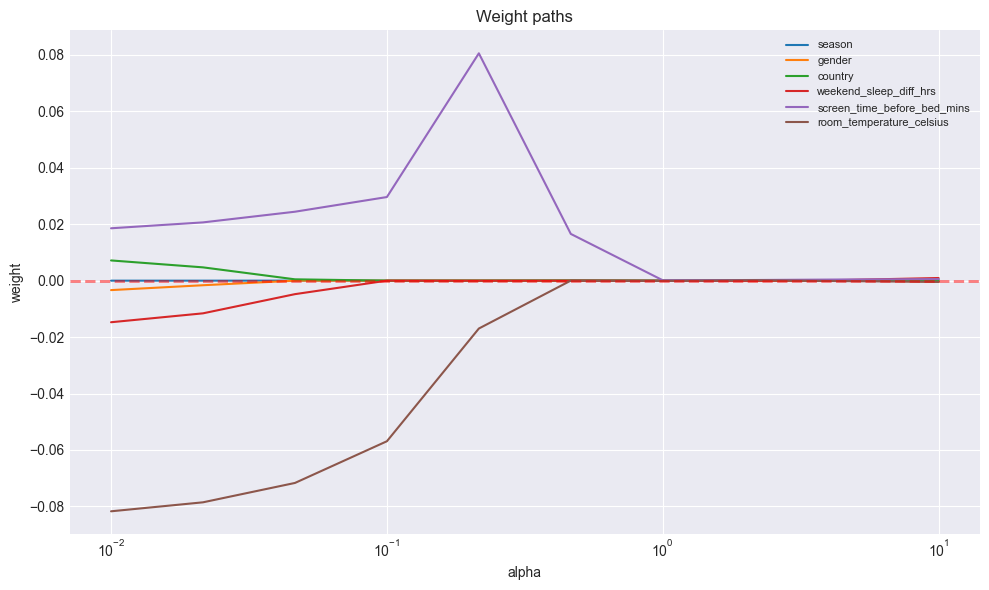

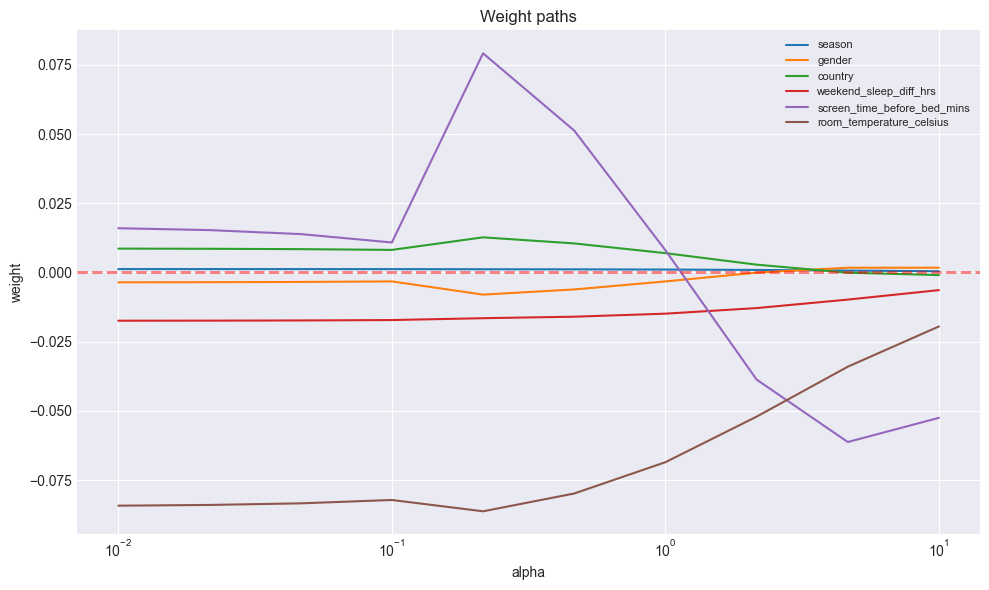

In [5]:
alphas = np.logspace(-2, 1, 10)
learning_rate = 0.0001
epochs = 4000
zero_tol = 1e-3
feature_names = X_encoded.columns.tolist()

stats = compare_lasso_ridge(
    X_train_scaled,
    np.asarray(y_train),
    alphas,
    learning_rate=learning_rate,
    epochs=epochs,
    zero_tol=zero_tol,
    feature_names=feature_names)

stats

## Wnioski
* Dla Lasso wyraźnie widać efekt selekcji zmiennych, gdzie wraz ze wzrostem siły regularyzacji alfa kolejne wagi odpadają z modelu, osiągając równe zero.

* Ridge działa znacznie łagodniej – zmniejsza wartości współczynników, skutecznie je ograniczając, ale zostawia wpływ wszystkich cech.

# Zestawienie regularyzacji regresji

,penalty,alpha,train_mse,test_mse,train_mae,test_mae,zero_count,mean_abs_weight
0,l1,0.000000,780.809044,783.440978,26.661672,26.716115,0,1.252981
1,l1,0.001000,780.810551,783.441174,26.661667,26.716087,1,1.252821
2,l1,0.002154,780.812299,783.441424,26.661662,26.716056,1,1.252636
3,l1,0.004642,780.816094,783.442054,26.661650,26.715989,1,1.252232
4,l1,0.010000,780.824392,783.443874,26.661626,26.715849,1,1.251387
5,l1,0.021544,780.842805,783.448821,26.661576,26.715559,1,1.249509
6,l1,0.046416,780.884507,783.459358,26.661470,26.714897,3,1.245528
7,l1,0.100000,780.982935,783.483856,26.661247,26.713365,4,1.237507
8,l1,0.215443,781.235810,783.566226,26.660823,26.709949,4,1.219913
9,l1,0.464159,781.944052,783.905726,26.660089,26.702797,6,1.182103


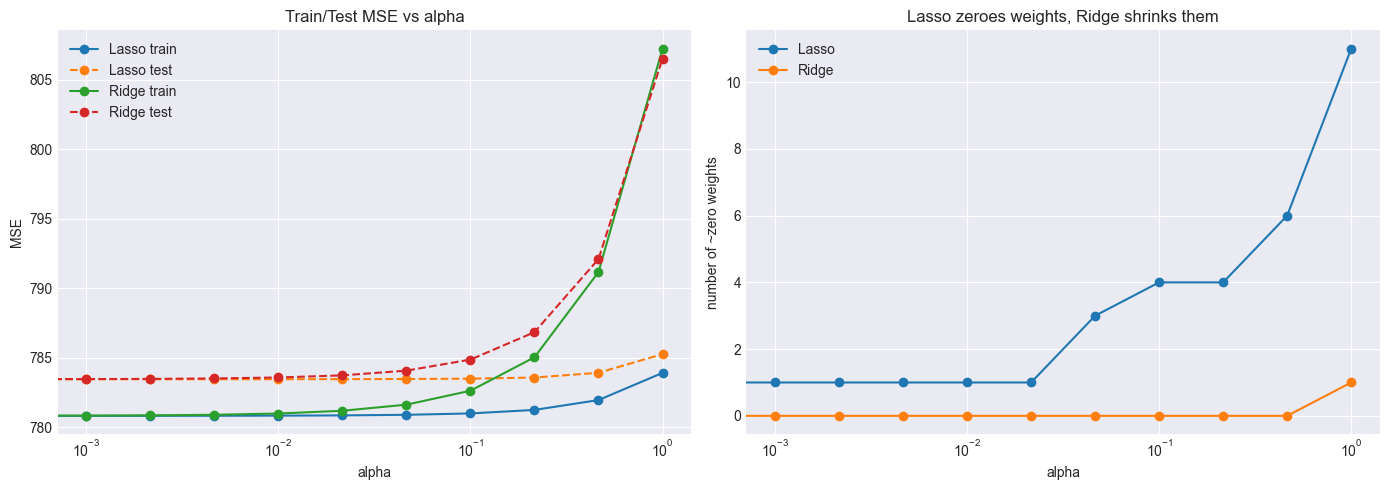

In [6]:
regression_alphas = np.r_[0.0, np.logspace(-3, 0, 10)]
learning_rate = 0.0001
epochs = 4000

regression_results = regularized_regression_results(
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    alphas=regression_alphas,
    learning_rate=learning_rate,
    epochs=epochs,
)

display(regression_results.sort_values(["penalty", "alpha"]))

plot_comparison_results(regression_results)
plt.show()

## Wnioski
Przy bardzo małych wartościach alpha oba modele zachowują się jak klasyczna regresja, przez co błąd treningowy jest stosunkowo mały, ale na zbiorze testowym widać delikatny overfitting.

Optymalny punkt osiągamy dla średnich wartości parametru alpha, gdzie błąd testowy spada do swojego minimum, co oznacza, że model najlepiej uogólnia wiedzę na nowych danych.

Przekroczenie krytycznej wartości alpha powoduje drastyczny wzrost błędu zarówno na treningu, jak i na teście. Model wpada w silny underfitting.

# Regularyzacja drzew decyzyjnych


In [7]:
X_tree, y_tree = data_preprocessing.extract_target(df_encoded, target_col_cat)

X_tree_train, X_tree_test, y_tree_train, y_tree_test = train_test_split(
    X_tree, y_tree, test_size=0.2, random_state=13, stratify=y_tree
)

scaler_reg = StandardScaler()
X_tree_train_scaled = scaler_reg.fit_transform(X_tree_train)
X_tree_test_scaled = scaler_reg.transform(X_tree_test)

tree_baseline = fit_tree_classifier(
    X_tree_train_scaled, y_tree_train,
    criterion="entropy",
    random_state=13,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None,
)
baseline_tree_metrics = evaluate_tree_classifier(
    tree_baseline, X_tree_train_scaled, y_tree_train, X_tree_test_scaled, y_tree_test
)
pd.Series({k: v for k, v in baseline_tree_metrics.items() if not k.endswith("_pred")})


train_accuracy                  1.000000
test_accuracy                   0.671250
train_precision_weighted        1.000000
test_precision_weighted         0.671425
train_recall_weighted           1.000000
test_recall_weighted            0.671250
train_f1_weighted               1.000000
test_f1_weighted                0.671337
depth                          49.000000
n_leaves                    10762.000000
dtype: float64

## Wnioski dla podstawowego drzewa
Dla nieograniczonego drzewa decyzyjnego dokładność na zbiorze treningowym jest idealnie równa 100%. Jednak dla zbioru testowego celność wynosi tylko ~67%. Model jest mocno przeuczony.

In [8]:
tree_sweeps = {}

tree_sweeps["min_samples_split"] = sweep_tree_parameter(
    X_tree_train_scaled,
    y_tree_train,
    X_tree_test_scaled,
    y_tree_test,
    param_name="min_samples_split",
    param_values=[50, 500, 2000, 5000, 10000],
    base_params={
        "criterion": "entropy",
        "random_state": 13,
        "max_depth": None,
        "min_samples_leaf": 1,
        "max_features": None,
    },
)

tree_sweeps["min_samples_leaf"] = sweep_tree_parameter(
    X_tree_train_scaled,
    y_tree_train,
    X_tree_test_scaled,
    y_tree_test,
    param_name="min_samples_leaf",
    param_values=[50, 500, 1000, 2000, 5000],
    base_params={
        "criterion": "entropy",
        "random_state": 13,
        "max_depth": None,
        "min_samples_split": 2,
        "max_features": None,
    },
)

tree_sweeps["max_features"] = sweep_tree_parameter(
    X_tree_train_scaled,
    y_tree_train,
    X_tree_test_scaled,
    y_tree_test,
    param_name="max_features",
    param_values=[None, "sqrt", "log2", 10, 20],
    base_params={
        "criterion": "entropy",
        "random_state": 13,
        "max_depth": None,
        "min_samples_split": 1000,
        "min_samples_leaf": 100,
    },
)



min_samples_split:


,setting,train_accuracy,test_accuracy,train_f1_weighted,test_f1_weighted,depth,n_leaves
0,50,0.832200,0.69445,0.831548,0.693348,43,3111
1,500,0.757275,0.72585,0.756703,0.724640,23,457
2,2000,0.743400,0.73595,0.742016,0.734288,14,89
3,5000,0.740550,0.73770,0.740302,0.736976,8,29
4,10000,0.735638,0.73555,0.733490,0.733132,5,12


Najlepsze ustawienie:


,param_name,param_value,param_label,train_accuracy,test_accuracy,train_precision_weighted,test_precision_weighted,train_recall_weighted,test_recall_weighted,train_f1_weighted,test_f1_weighted,depth,n_leaves
3,min_samples_split,5000,5000,0.74055,0.7377,0.74008,0.736445,0.74055,0.7377,0.740302,0.736976,8,29



min_samples_leaf:


...

,param_name,param_value,param_label,train_accuracy,test_accuracy,train_precision_weighted,test_precision_weighted,train_recall_weighted,test_recall_weighted,train_f1_weighted,test_f1_weighted,depth,n_leaves
1,min_samples_leaf,500,500,0.7444,0.7388,0.742565,0.736697,0.7444,0.7388,0.743232,0.737427,12,116



max_features:


,setting,train_accuracy,test_accuracy,train_f1_weighted,test_f1_weighted,depth,n_leaves
0,None,0.746812,0.73810,0.745567,0.736516,16,154
1,sqrt,0.735938,0.72850,0.734834,0.727179,12,149
2,log2,0.732250,0.72275,0.727701,0.717568,12,143
3,10,0.741587,0.73375,0.739421,0.731037,16,155
4,20,0.746838,0.73715,0.744500,0.734497,15,161


Najlepsze ustawienie:


,param_name,param_value,param_label,train_accuracy,test_accuracy,train_precision_weighted,test_precision_weighted,train_recall_weighted,test_recall_weighted,train_f1_weighted,test_f1_weighted,depth,n_leaves
0,max_features,None,None,0.746812,0.7381,0.744898,0.735761,0.746812,0.7381,0.745567,0.736516,16,154


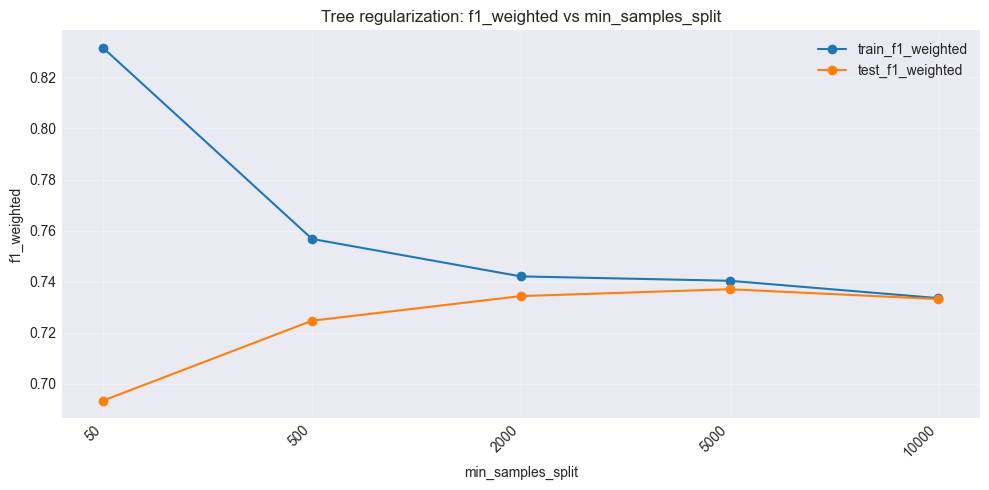

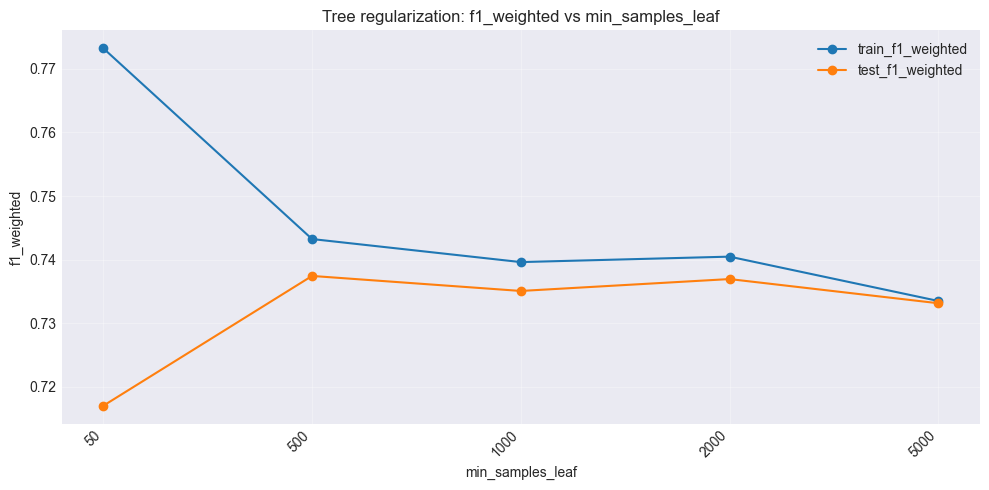

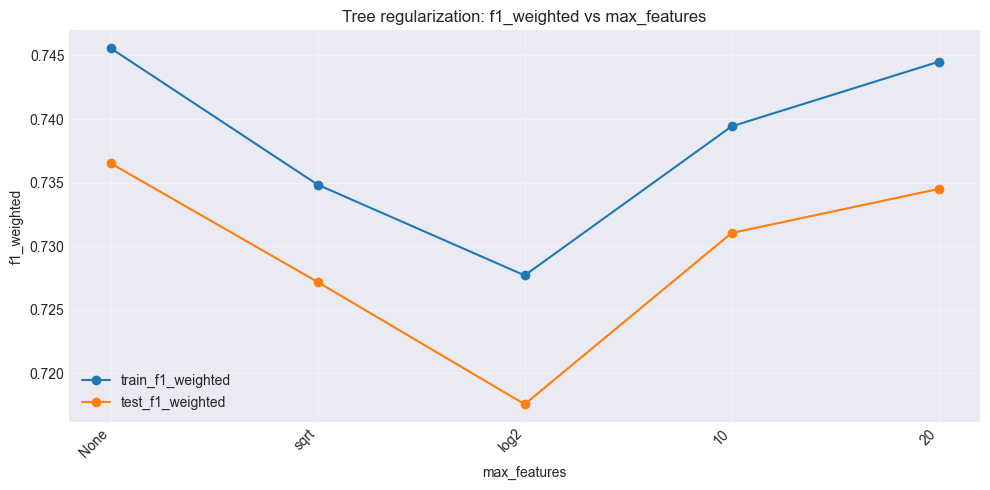

In [9]:
tree_summaries = {}

for name, df_results in tree_sweeps.items():
    summary, best_row = summarize_tree_sweep(df_results, metric="test_f1_weighted")
    tree_summaries[name] = {
        "summary": summary,
        "best": best_row,
    }
    print(f"\n{name}:")
    display(summary)
    print("Najlepsze ustawienie:")
    display(best_row.to_frame().T)
    plot_train_test_curves(df_results, metric="f1_weighted", param_label=name)

plt.show()


# Bagging (Bootstrap Aggregating)

### 1. Porównanie: Pojedyncze drzewo vs sklearn Bagging vs własna impelmentacja


In [10]:
single_tree = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=13
)
single_tree.fit(X_tree_train_scaled, y_tree_train)

sklearn_rf = RandomForestClassifier(
    n_estimators=20,
    criterion='entropy',
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=13,
    n_jobs=-1
)
sklearn_rf.fit(X_tree_train_scaled, y_tree_train)

custom_bagging = BaggingClassifier(
    n_estimators=20,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    criterion='entropy',
    random_state=13,
    bootstrap=True
)
custom_bagging.fit(X_tree_train_scaled, y_tree_train)

In [11]:
comparison_data = []
for name, model in [("Single Tree", single_tree), ("sklearn RF", sklearn_rf), ("Custom Bagging", custom_bagging)]:
    y_train_pred = model.predict(X_tree_train_scaled)
    y_test_pred = model.predict(X_tree_test_scaled)

    comparison_data.append({
        'Model': name,
        'Train Accuracy': accuracy_score(y_tree_train, y_train_pred),
        'Test Accuracy': accuracy_score(y_tree_test, y_test_pred),
        'Train F1': f1_score(y_tree_train, y_train_pred, average='weighted', zero_division=0),
        'Test F1': f1_score(y_tree_test, y_test_pred, average='weighted', zero_division=0),
        'Overfitting (gap)': accuracy_score(y_tree_train, y_train_pred) - accuracy_score(y_tree_test, y_test_pred),
    })

comparison_df = pd.DataFrame(comparison_data)
print("\nPorównanie wyników:")
display(comparison_df)



Porównanie wyników:


,Model,Train Accuracy,Test Accuracy,Train F1,Test F1,Overfitting (gap)
0,Single Tree,0.802625,0.70955,0.801595,0.708019,0.093075
1,sklearn RF,0.833750,0.73595,0.833019,0.734166,0.097800
2,Custom Bagging,0.814438,0.73695,0.812838,0.733858,0.077488


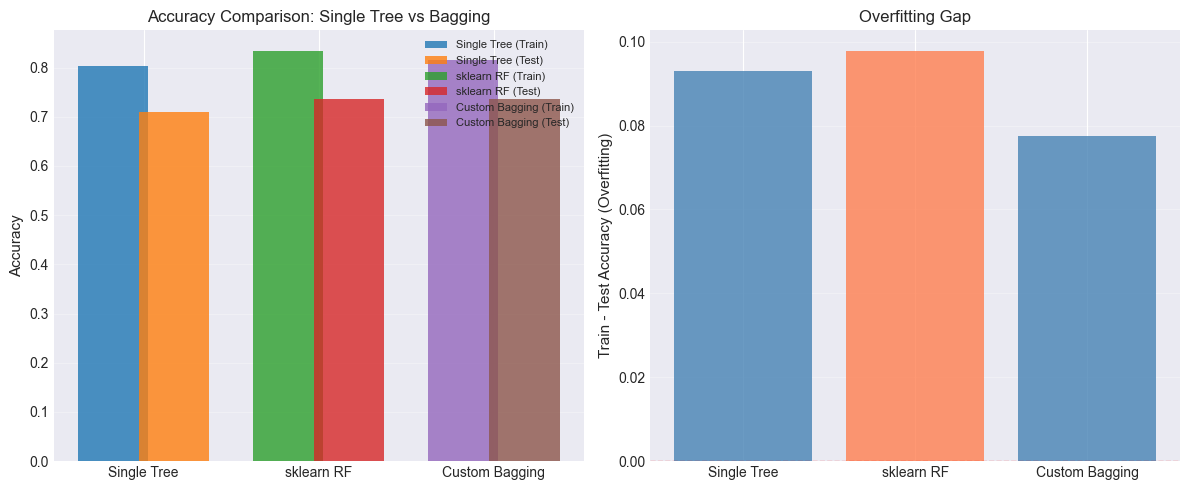

In [12]:
fig = plot_comparison_bars(comparison_df, figsize=(12, 5))
plt.show()

## Wnioski
Pojedyncze drzewo ma największą tendencję do przeuczenia. Dzięki uśrednieniu decyzji wielu modeli w RandomForest oraz własnym Baggingu błąd na zbiorze testowym spada, a cały system staje się dużo bardziej stabilny i odporny na szum.

Losowanie ze zwracaniem gwarantuje nam różnorodność w każdym z drzew. Dzięki niemu każde drzewo uczy się inaczej i daje bardziej zróżnicowane wyniki. Gdybyśmy wytrenowali 100 identycznych drzew na dokładnie tym samym zbiorze to każde z nich zwracałoby dokładnie te same wyniki, więc głosowanie z zespołu nie miało by sensu. W takim przypadku algorytm działa dokładnie jak pojedyncze drzewo, ale wymaga 100 razy większej mocy obliczeniowej.

### 2. Wpływ liczby drzew (n_estimators) na wydajność


In [13]:
n_estimators_list = [1, 3, 5, 10, 15, 20, 30, 50]

results_custom = []
for n_est in n_estimators_list:
    model = BaggingClassifier(
        n_estimators=n_est,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        criterion='entropy',
        random_state=13
    )
    model.fit(X_tree_train_scaled, y_tree_train)

    y_train_pred = model.predict(X_tree_train_scaled)
    y_test_pred = model.predict(X_tree_test_scaled)

    results_custom.append({
        'n_estimators': n_est,
        'train_accuracy': accuracy_score(y_tree_train, y_train_pred),
        'test_accuracy': accuracy_score(y_tree_test, y_test_pred),
        'train_f1': f1_score(y_tree_train, y_train_pred, average='weighted', zero_division=0),
        'test_f1': f1_score(y_tree_test, y_test_pred, average='weighted', zero_division=0),
    })

results_df = pd.DataFrame(results_custom)
print("Wpływ liczby drzew na wydajność (Custom Bagging):")
display(results_df)

Wpływ liczby drzew na wydajność (Custom Bagging):


,n_estimators,train_accuracy,test_accuracy,train_f1,test_f1
0,1,0.778450,0.69430,0.777534,0.692564
1,3,0.802625,0.71730,0.801728,0.715501
2,5,0.809013,0.72485,0.808458,0.723400
3,10,0.811813,0.73145,0.810081,0.728031
4,15,0.813725,0.73620,0.812833,0.734297
5,20,0.814438,0.73695,0.812838,0.733858
6,30,0.816950,0.73815,0.815623,0.735541
7,50,0.817113,0.73860,0.815884,0.736214


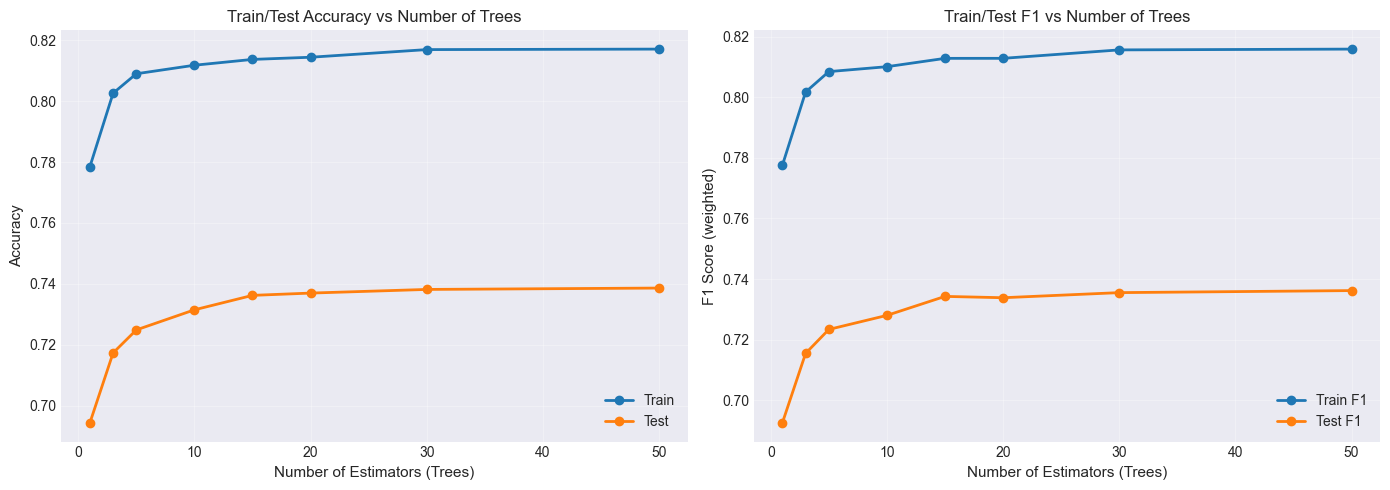

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results_df['n_estimators'], results_df['train_accuracy'], marker='o', label='Train', linewidth=2)
axes[0].plot(results_df['n_estimators'], results_df['test_accuracy'], marker='o', label='Test', linewidth=2)
axes[0].set_xlabel('Number of Estimators (Trees)', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_title('Train/Test Accuracy vs Number of Trees', fontsize=12)
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

axes[1].plot(results_df['n_estimators'], results_df['train_f1'], marker='o', label='Train F1', linewidth=2)
axes[1].plot(results_df['n_estimators'], results_df['test_f1'], marker='o', label='Test F1', linewidth=2)
axes[1].set_xlabel('Number of Estimators (Trees)', fontsize=11)
axes[1].set_ylabel('F1 Score (weighted)', fontsize=11)
axes[1].set_title('Train/Test F1 vs Number of Trees', fontsize=12)
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Stacking

In [15]:
level_0_models = [
    DecisionTreeRegressor(max_depth=5, random_state=42),
    KNeighborsRegressor(n_neighbors=5),
    RegularizedGD(
        learning_rate=0.01,
        alpha=0.1,
        epochs=3000,
        penalty="l2",
        is_classifier=False
    )
]

level_1_model = LinearRegression()

stacking_classifier = StackingModel(
    base_models=level_0_models,
    meta_model=level_1_model,
    cv=5
)

stacking_classifier.fit(X_train_scaled, y_train)

y_pred_train = stacking_classifier.predict(X_train_scaled)
y_pred_test = stacking_classifier.predict(X_test_scaled)

mse_train = mse(y_train, y_pred_train)
mse_test = mse(y_test, y_pred_test)
mae_train = mae(y_train, y_pred_train)
mae_test = mae(y_test, y_pred_test)

print(f"Train MSE: {mse_train:.4f}")
print(f"Test MSE: {mse_test:.4f}")
print(f"Train MAE: {mae_train:.4f}")
print(f"Test MAE: {mae_test:.4f}")

print("Wagi przypisane modelom Level-0: ", stacking_classifier.meta_model.coef_)

Train MSE: 47.6828
Test MSE: 49.7253
Train MAE: 5.4425
Test MAE: 5.5484
Wagi przypisane modelom Level-0:  [0.17770473 0.09877937 0.78748043]


# Boosting

In [16]:
boosting_model = SimpleGradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42)

single_tree = DecisionTreeRegressor(
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=13
)

regularized_gd_regressor = RegularizedGD(
        learning_rate=0.01,
        alpha=0.1,
        epochs=3000,
        penalty="l2",
        is_classifier=False
    )

level_0_models = [
    DecisionTreeRegressor(max_depth=5, random_state=42),
    KNeighborsRegressor(n_neighbors=5),
    RegularizedGD(
        learning_rate=0.0001,
        alpha=0.1,
        epochs=4000,
        penalty="l1",
        is_classifier=False
    )
]

level_1_model = LinearRegression()

stacking_regressor = StackingModel(
    base_models=level_0_models,
    meta_model=level_1_model,
    cv=5
)


models_to_compare = {
    "Pojedyncze Drzewo Decyzyjne": single_tree,
    "Zregulowany Gradient Descent": regularized_gd_regressor,
    "Stacking Model": stacking_regressor,
    "Gradient Boosting (100 drzew)": boosting_model
}

Nazwa Modelu                             | Train MSE  | Test MSE   | Train MAE  | Test MAE  
------------------------------------------------------------------------------------------
Pojedyncze Drzewo Decyzyjne              | 23.1240    | 66.6299    | 3.7277     | 6.4376    
Zregulowany Gradient Descent             | 52.4122    | 52.4558    | 5.7228     | 5.7233    
Stacking Model                           | 52.8597    | 57.3537    | 5.7344     | 5.9581    
Gradient Boosting (100 drzew)            | 42.7135    | 43.4355    | 5.2309     | 5.2589    


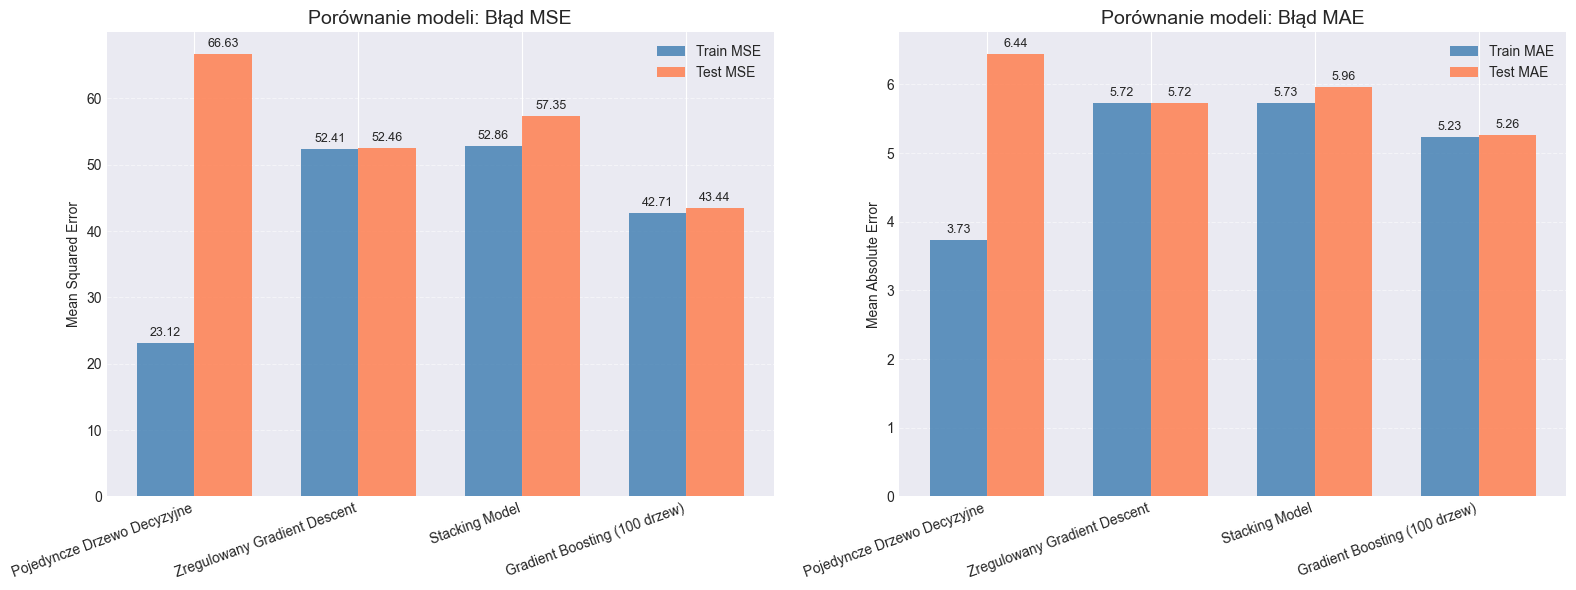

In [17]:
evaluate_and_plot_models(models_to_compare, X_train_scaled, y_train, X_test_scaled, y_test)

## Wnioski
Pojedyncze drzewo jest klasycznie przeuczone. Zregulowany Gradient Descent jest stabliny, ale nie osiąga najlepszych wyników. Stacking i Boosting dają znacznie lepsze testy, jednak Boosting daje lepsze wyniki MSE i MAE.

# Mixture of experts

Architektura              | Train MSE  | Test MSE   | Test R2   
---------------------------------------------------------------------------
Globalny Ekspert          | 49.9774    | 50.2129    | 0.8987    
Mixture of Experts        | 42.1957    | 42.7424    | 0.9138    


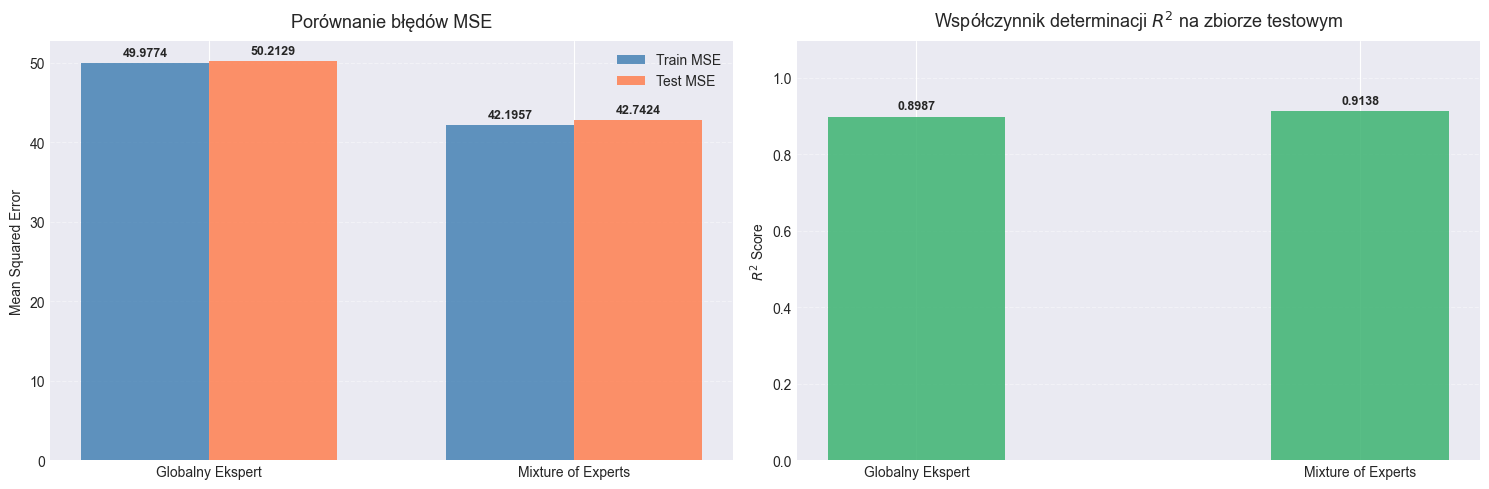

In [18]:
moe_model = MoERegressor(k_clusters=6, random_state=42)
moe_model.fit(X_train_scaled, y_train)

global_expert = Ridge(alpha=1.0)
global_expert.fit(X_train_scaled, y_train)

evaluate_and_plot_moe_vs_global(global_expert, moe_model, X_train_scaled, y_train, X_test_scaled, y_test)

## Wnioski
Mixture of experts jest bardzo dobrym algorytmem. Dobrze skonfigurowany jest odporny na overfitting oraz ma najniższy błąd ze wszystkich testowanych algorytmów.

Spadek błędu w modelu MoE jest bezpośrednim dowodem na to, że KMeans podzielił pacjentów w sensowny i obiektywnie użyteczny sposób. Algorytm grupujący sensownie i użytecznie podzielił zbiór, znajdując podzbiory. Zamiast zmuszać jeden model do szukania kompromisu między wszystkimi danymi, algorytm MoE pozwala każdemu z model wyspecjalizować się w swoim podzbiorze.

Delegowanie jednego konkretnego eksperta jest bardziej wiarygodne i podlega mniejszej losowości, niż odpalenie pełnego 100-drzewnego lasu losowego, ponieważ ekspert musiał być wcześniej przydzielony przez bramkę, która zdecydowała, że ten konkretny model jest w stanie sobie dobrze poradzić z danymi.